# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

from plotnine import *
# %pip install --upgrade plotnine mizani pandas_datareader setuptools

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [3]:
df =\
(
    yf.download(["WMT", "IBM"], 
        start = dt.datetime(2014, 10, 13), 
        end = dt.datetime(2022, 9, 13), 
        auto_adjust = True)['Close']
)

[*********************100%***********************]  2 of 2 completed


In [4]:
df_ibm = df[['IBM']]
df_wmt = df[['WMT']]

In [5]:
df_ibm, df_wmt

(Ticker             IBM
 Date                  
 2014-10-13  110.969650
 2014-10-14  111.138992
 2014-10-15  109.899391
 2014-10-16  108.744484
 2014-10-17  110.080803
 ...                ...
 2022-09-06  112.858368
 2022-09-07  113.740074
 2022-09-08  114.416939
 2022-09-09  115.058174
 2022-09-12  116.367386
 
 [1993 rows x 1 columns],
 Ticker            WMT
 Date                 
 2014-10-13  20.890921
 2014-10-14  21.004044
 2014-10-15  20.255247
 2014-10-16  19.883539
 2014-10-17  19.958956
 ...               ...
 2022-09-06  42.455513
 2022-09-07  43.546253
 2022-09-08  43.767605
 2022-09-09  43.899139
 2022-09-12  44.293732
 
 [1993 rows x 1 columns])

### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [6]:
df_ibm['SMA_20'] = df_ibm['IBM'].rolling(window = 20).mean()
df_ibm['SMA_60'] = df_ibm['IBM'].rolling(window = 60).mean()
df_ibm

Ticker,IBM,SMA_20,SMA_60
Date,,,
2014-10-13,110.969650,NaN,NaN
2014-10-14,111.138992,NaN,NaN
2014-10-15,109.899391,NaN,NaN
2014-10-16,108.744484,NaN,NaN
2014-10-17,110.080803,NaN,NaN
...,...,...,...
2022-09-06,112.858368,118.212282,118.906039
2022-09-07,113.740074,118.133908,118.805319
2022-09-08,114.416939,117.998980,118.731711


In [7]:
## Set index to datetime and fill with 0
BUY_or_SELL =\
(
    pd
    .DataFrame(index = df_ibm.index) # investment universe
)
BUY_or_SELL["BUY_or_SELL"] = 0.0
# set the short and long SMA columns
BUY_or_SELL["SMA_20"] =\
(                
    df_ibm['SMA_20']
)
BUY_or_SELL["SMA_60"] =\
(                
    df_ibm['SMA_60']
)
# assign signal
long = 60   # skip NaN values
BUY_or_SELL.loc[BUY_or_SELL.index[long:], "BUY_or_SELL"] =\
( 
    np # if else        # RULE       , True, False
    .where(BUY_or_SELL["SMA_20"][long: ] > BUY_or_SELL["SMA_60"][long: ],
           1.0, -1.0 # team, we are not short-selling when momentum is lost --> pay attention 
           # 1.0 being momentum is activated
           # 0.0 being momentum is lost
           )
)
BUY_or_SELL['BUY_or_SELL'].describe()

count    1993.000000
mean        0.027597
std         0.984693
min        -1.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: BUY_or_SELL, dtype: float64

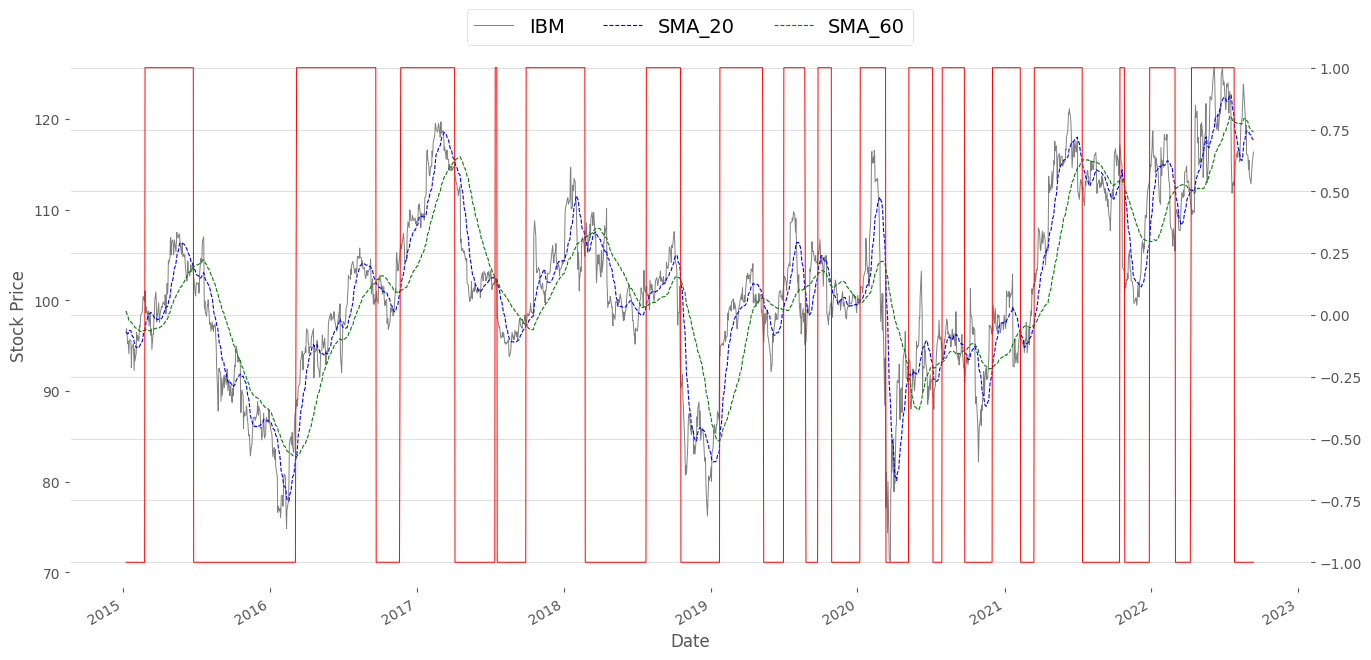

In [8]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    df_ibm
    ["IBM"][long:]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    BUY_or_SELL.loc[BUY_or_SELL.index[long:]]
    [["SMA_20", "SMA_60"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"],
          color = ["blue", "green"]
         )
)

# Add secondary axis
sub2 = sub.twinx()

# Plot BUY_or_SELL signal
(
    BUY_or_SELL['BUY_or_SELL'].loc[BUY_or_SELL.index[long:]]
    .plot(ax=sub2, 
          lw=0.7, 
          style="-", 
          color="red")
)

# Combine legends and place at top
lines, labels = sub.get_legend_handles_labels()
lines2, labels2 = sub2.get_legend_handles_labels()
sub.grid(False)
sub.legend(lines, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)
if sub2.get_legend():
    sub2.get_legend().remove()


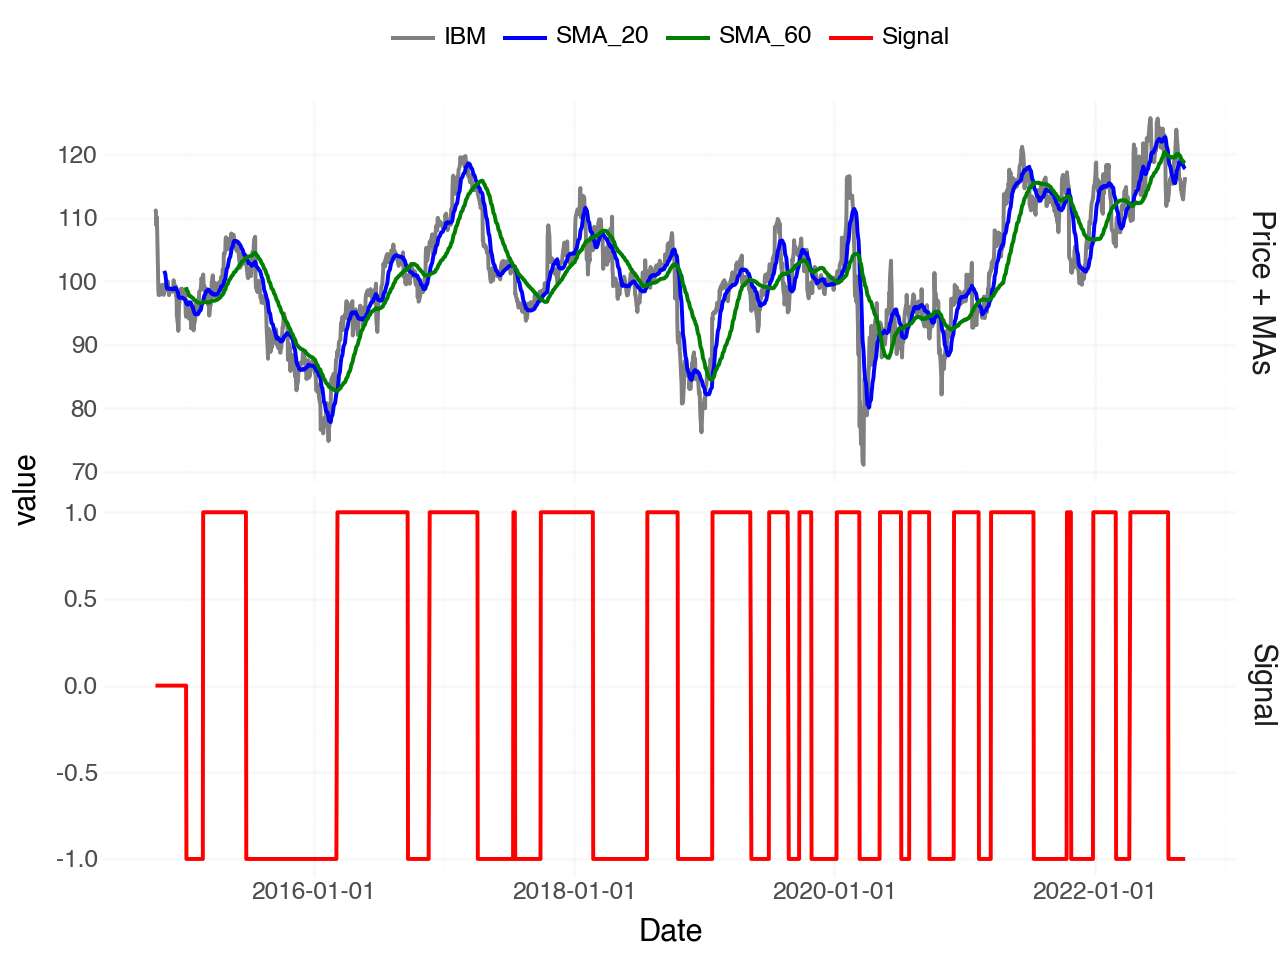

In [9]:
from plotnine import *

# --- Price & MAs ---
df_price = (
    pd.concat([
        df_ibm.assign(Date=df_ibm.index)[['Date','IBM']]
            .rename(columns={'IBM':'value'}).assign(Series='IBM'),
        BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','SMA_20']]
            .rename(columns={'SMA_20':'value'}).assign(Series='SMA_20'),
        BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','SMA_60']]
            .rename(columns={'SMA_60':'value'}).assign(Series='SMA_60')
    ], ignore_index=True)
)
df_price['Panel'] = 'Price + MAs'

# --- Signal ---
df_signal = (
    BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','BUY_or_SELL']]
        .rename(columns={'BUY_or_SELL':'value'})
        .assign(Series='Signal', Panel='Signal')
)

# --- Combine ---
df_all = pd.concat([df_price, df_signal], ignore_index=True)

# --- Plot ---
p = (
    ggplot(df_all, aes(x='Date', y='value', color='Series'))
    + geom_line(size=0.8)
    + facet_grid('Panel ~ .', scales="free_y")
    + scale_color_manual(values={
        "IBM":"grey", "SMA_20":"blue", "SMA_60":"green", "Signal":"red"
    })
    + theme_minimal()
    + theme(
        legend_position="top",
        legend_title=element_blank(),
        strip_text=element_text(size=11, weight="bold")
    )
)

p


### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [10]:
df_ibm = df_ibm.loc[BUY_or_SELL.index[long:]]

<Axes: xlabel='Date'>

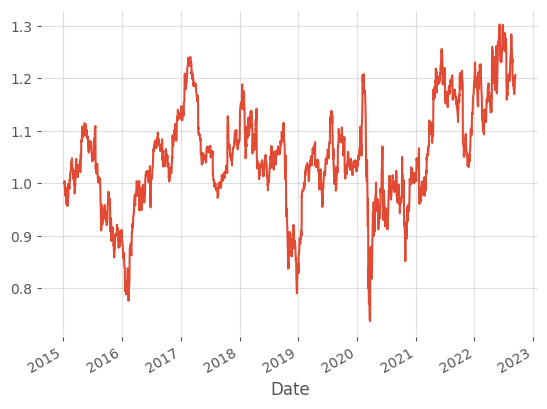

In [11]:
(df_ibm['IBM'].pct_change().fillna(0) + 1).cumprod().plot()

In [12]:
df_ibm['RETURNS'] =\
(
    (df_ibm['IBM'].pct_change().fillna(0) + 1).cumprod()
)

In [13]:
df =\
(    pd.concat([df_ibm, 
           BUY_or_SELL.loc[BUY_or_SELL.index[long:]][['BUY_or_SELL']]],
          axis=1))

In [14]:
df['STRATEGY'] =\
(
    df['IBM'].pct_change().fillna(0) * df['BUY_or_SELL'] + 1
).cumprod()

<Axes: xlabel='Date'>

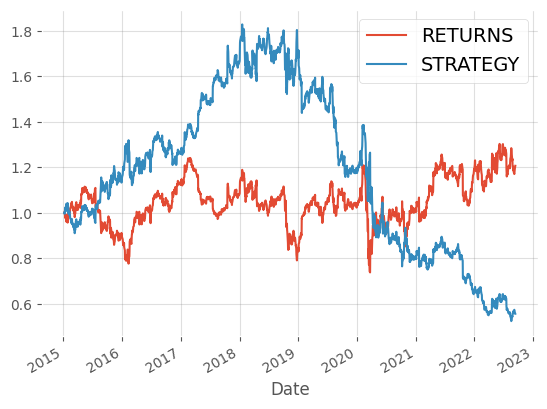

In [15]:
df[['RETURNS', 'STRATEGY']].plot()

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [16]:
window = len(df_ibm)

rolling_max =\
(
    df_ibm
    ['IBM']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

daily_drawdown =\
(
    df_ibm['IBM'] / rolling_max - 1.0
)

daily_drawdown 

Date
2015-01-08    0.000000
2015-01-09    0.000000
2015-01-12   -0.016781
2015-01-13   -0.014455
2015-01-14   -0.020803
                ...   
2022-09-06   -0.101928
2022-09-07   -0.094911
2022-09-08   -0.089525
2022-09-09   -0.084423
2022-09-12   -0.074005
Name: IBM, Length: 1933, dtype: float64

In [17]:
max_daily_drawdown =\
(
    daily_drawdown
    .rolling(window = window, 
             min_periods = 1)
    .min()
)

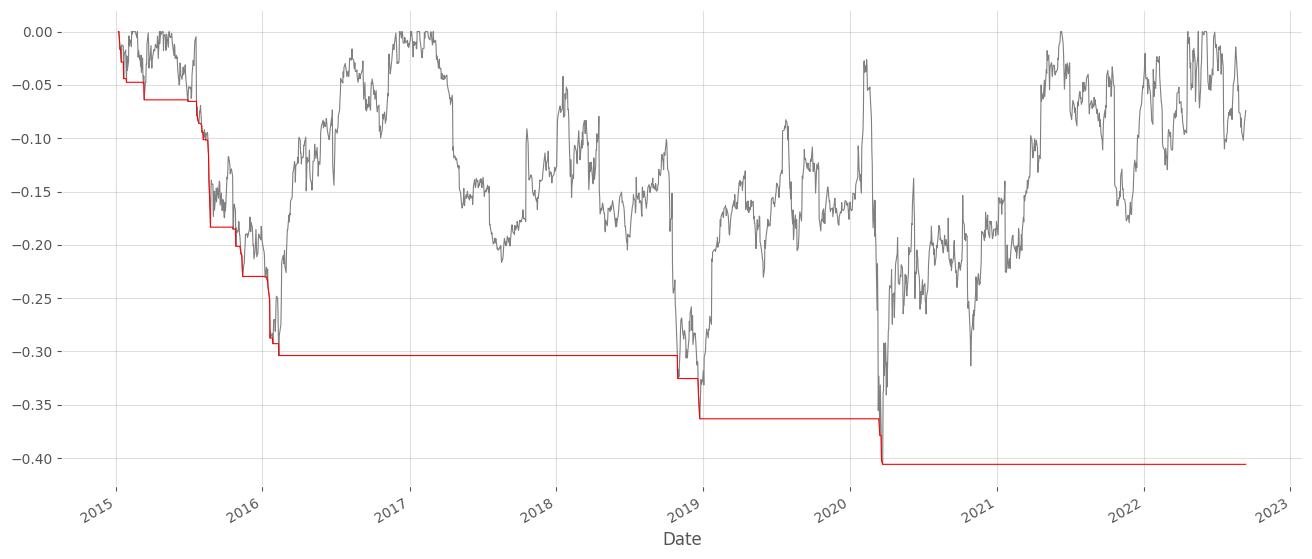

In [18]:
fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)

plt.show()

In [19]:
max_daily_drawdown.min(), 

(np.float64(-0.4058519423065682),)

In [20]:
streaks = (max_daily_drawdown != max_daily_drawdown.shift()).cumsum()   # increments when value changes
longest = max_daily_drawdown.groupby(streaks).size().max()

print("Longest streak length:", longest)

Longest streak length: 685


<Axes: xlabel='Date'>

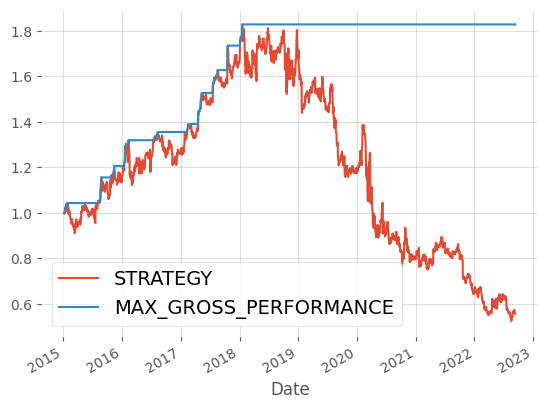

In [21]:
window = len(df_ibm)

rolling_max =\
(
    df
    ['STRATEGY']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

df['MAX_GROSS_PERFORMANCE'] = rolling_max

df[['STRATEGY', 'MAX_GROSS_PERFORMANCE']].plot()

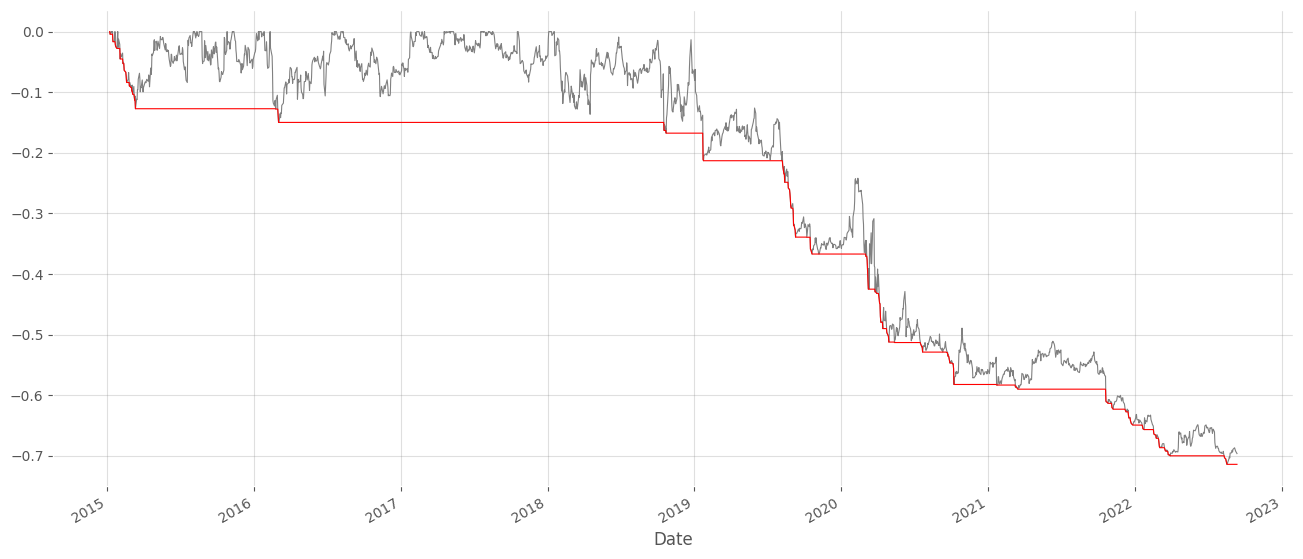

In [22]:

daily_drawdown =\
(
    df['STRATEGY'] / rolling_max - 1.0
)


rolling_max =\
(
    df['STRATEGY']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

max_daily_drawdown =\
(
    daily_drawdown
    .rolling(window = window, 
             min_periods = 1)
    .min()
)

fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)

plt.show()

In [23]:
streaks = (rolling_max != rolling_max.shift()).cumsum()   # increments when value changes
longest = rolling_max.groupby(streaks).size().max()

In [24]:

print(f"The maximum drawdown is about {max_daily_drawdown.min()*100:.2f} percentage points.")
print(f"The longest drawdown period lasts for {longest} days.")

The maximum drawdown is about -71.40 percentage points.
The longest drawdown period lasts for 1171 days.


### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [25]:
## Set index to datetime and fill with 0
BUY_or_SELL =\
(
    pd
    .DataFrame(index = df_wmt.index) # investment universe
)
BUY_or_SELL["BUY_or_SELL"] = 0.0
# set the short and long SMA columns
BUY_or_SELL["SMA_50"] =\
(
    df_wmt['WMT'].rolling(window = 50).mean()
)
BUY_or_SELL["SMA_200"] =\
(
    df_wmt['WMT'].rolling(window = 200).mean()
)
# assign signal
long = 200   # skip NaN values
BUY_or_SELL.loc[BUY_or_SELL.index[long:], "BUY_or_SELL"] =\
( 
    np # if else        # RULE       , True, False
    .where(BUY_or_SELL["SMA_50"][long: ] > BUY_or_SELL["SMA_200"][long: ],
           1.0, -1.0 # team, we are not short-selling when momentum is lost --> pay attention 
           # 1.0 being momentum is activated
           # 0.0 being momentum is lost
           )
)

BUY_or_SELL['WMT'] = df_wmt['WMT']

BUY_or_SELL['BUY_or_SELL'].describe()

count    1993.000000
mean        0.362770
std         0.876603
min        -1.000000
25%        -1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: BUY_or_SELL, dtype: float64

In [26]:
BUY_or_SELL =\
(
    BUY_or_SELL.loc[BUY_or_SELL.index[long:]]
)

In [27]:
BUY_or_SELL["positions"] =\
(
    BUY_or_SELL["BUY_or_SELL"]
    .diff()
)

BUY_or_SELL[['BUY_or_SELL', 'SMA_50', 'SMA_200', 'positions']]

,BUY_or_SELL,SMA_50,SMA_200,positions
Date,,,,
2015-07-30,-1.0,20.055918,21.788871,NaN
2015-07-31,-1.0,20.034421,21.782537,0.0
2015-08-03,-1.0,20.012868,21.780220,0.0
2015-08-04,-1.0,19.993071,21.779858,0.0
2015-08-05,-1.0,19.988201,21.781535,0.0
...,...,...,...,...
2022-09-06,-1.0,41.549546,43.848763,0.0
2022-09-07,-1.0,41.627555,43.840473,0.0
2022-09-08,-1.0,41.721170,43.834505,0.0


In [28]:
BUY_or_SELL['positions'].unique()

array([nan,  0.,  2., -2.])

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_73236/2814123913.py:40: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter


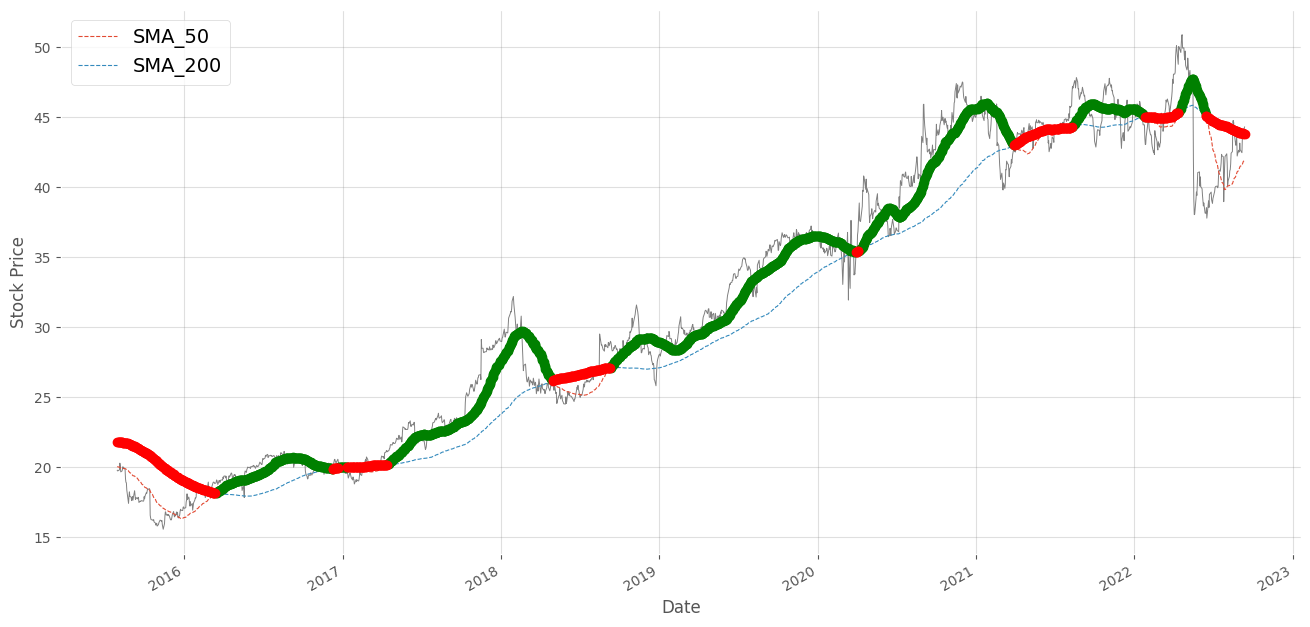

In [ ]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    BUY_or_SELL
    ["WMT"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    BUY_or_SELL
    [["SMA_50", "SMA_200"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# BUY Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == 2.0].index,
          BUY_or_SELL.SMA_50[BUY_or_SELL.positions == 2.0],
          ".",
          color = "green",
          markersize = 12)
)

# SELL Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == -2.0].index,
          BUY_or_SELL.SMA_50[BUY_or_SELL.positions == -2.0],
          ".",
          color = "red",
          markersize = 12)
)

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>